# 02. Data Science Fundamentals

This notebook summarizes the basic workflow used in data science: defining a question, loading data, checking its quality, cleaning and transforming values, calculating descriptive statistics, and communicating patterns with visualizations. The examples use a small synthetic sales dataset so that every step can run without an internet connection.

## 0. Install the Required Libraries

NumPy supports efficient numerical operations, pandas provides table-based data analysis, and Matplotlib and Seaborn create visualizations. Run this installation cell only when the libraries are not already available.

In [1]:
%pip install -q numpy pandas matplotlib seaborn

Note: you may need to restart the kernel to use updated packages.


## 1. Import the Libraries and Configure the Environment

Aliases such as `np`, `pd`, `plt`, and `sns` are standard conventions in Python data-science projects. A fixed random seed makes generated examples reproducible.

In [2]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from IPython.display import display

rng = np.random.default_rng(42)
plt.style.use("seaborn-v0_8-whitegrid")
sns.set_palette("Set2")
pd.set_option("display.max_columns", 20)

## 2. NumPy Arrays and Vectorized Calculations

A NumPy array stores values of a consistent type and performs calculations across an entire collection at once. Vectorized operations are usually clearer and faster than manually processing one value at a time. Shape describes the dimensions of an array, while aggregation methods summarize its contents.

In [4]:
prices = np.array([12000, 15500, 9800, 21000, 18500], dtype=float)
quantities = np.array([3, 2, 5, 1, 4])
revenue = prices * quantities

print("Array shape:", prices.shape)
print("Revenue by transaction:", revenue)
print("Total revenue:", revenue.sum())
print("Average price:", prices.mean())
print("Price standard deviation:", prices.std())

Array shape: (5,)
Revenue by transaction: [36000. 31000. 49000. 21000. 74000.]
Total revenue: 211000.0
Average price: 15360.0
Price standard deviation: 4096.144528700129


## 3. Create a pandas DataFrame

A DataFrame is a two-dimensional table with named columns and an index. Each column may have a different data type. In real projects, data is commonly loaded with functions such as `pd.read_csv()`, `pd.read_excel()`, or a database query. Here, a reproducible DataFrame is created directly.

In [8]:
dates = pd.date_range("2026-01-01", periods=120, freq="D")
products = rng.choice(["Laptop", "Tablet", "Phone"], size=120, p=[0.25, 0.30, 0.45])
regions = rng.choice(["Seoul", "Busan", "Daejeon"], size=120)
unit_price_map = {"Laptop": 1500, "Tablet": 700, "Phone": 950}

df = pd.DataFrame({
    "date": dates,
    "product": products,
    "region": regions,
    "quantity": rng.integers(1, 8, size=120),
    "unit_price": [unit_price_map[p] for p in products],
    "customer_rating": np.round(rng.normal(4.1, 0.55, size=120), 1),
})

# Introduce a few missing ratings to demonstrate data cleaning.
missing_rows = rng.choice(df.index, size=6, replace=False)
df.loc[missing_rows, "customer_rating"] = np.nan

display(df.iloc[1:20 , :])

,date,product,region,quantity,unit_price,customer_rating
1,2026-01-02,Tablet,Daejeon,2,700,3.7
2,2026-01-03,Phone,Daejeon,1,950,4.9
3,2026-01-04,Phone,Daejeon,6,950,3.8
4,2026-01-05,Tablet,Busan,3,700,5.3
5,2026-01-06,Tablet,Seoul,5,700,4.1
6,2026-01-07,Laptop,Seoul,4,1500,4.3
7,2026-01-08,Tablet,Seoul,6,700,5.0
8,2026-01-09,Phone,Busan,6,950,4.2
9,2026-01-10,Laptop,Daejeon,3,1500,3.5
10,2026-01-11,Tablet,Busan,6,700,4.0


## 4. Inspect Structure and Data Quality

Inspection should happen before analysis. `shape` reports the number of rows and columns, `dtypes` shows how values are stored, and `info()` summarizes non-null counts. Duplicate and missing-value checks help identify issues that could distort later calculations.

In [9]:
print("Shape:", df.shape)
print()
print("Data types:")
print(df.dtypes)
print()
print("Missing values:")
print(df.isna().sum())
print()
print("Duplicate rows:", df.duplicated().sum())
print()
print("DataFrame information:")
df.info()

Shape: (120, 6)

Data types:
date               datetime64[us]
product                       str
region                        str
quantity                    int64
unit_price                  int64
customer_rating           float64
dtype: object

Missing values:
date               0
product            0
region             0
quantity           0
unit_price         0
customer_rating    6
dtype: int64

Duplicate rows: 0

DataFrame information:
<class 'pandas.DataFrame'>
RangeIndex: 120 entries, 0 to 119
Data columns (total 6 columns):
 #   Column           Non-Null Count  Dtype         
---  ------           --------------  -----         
 0   date             120 non-null    datetime64[us]
 1   product          120 non-null    str           
 2   region           120 non-null    str           
 3   quantity         120 non-null    int64         
 4   unit_price       120 non-null    int64         
 5   customer_rating  114 non-null    float64       
dtypes: datetime64[us](1), float64(1)

## 5. Clean and Validate the Data

Cleaning decisions should reflect the meaning of the data. Missing customer ratings are filled with the median because it is resistant to extreme values. Ratings are then constrained to the valid 1-to-5 range. Dates are explicitly converted to a datetime type, and duplicate rows are removed.

In [10]:
clean = df.copy()
clean["date"] = pd.to_datetime(clean["date"], errors="coerce")
clean = clean.drop_duplicates()
clean["customer_rating"] = clean["customer_rating"].fillna(
    clean["customer_rating"].median()
)
clean["customer_rating"] = clean["customer_rating"].clip(1, 5)

assert clean["date"].notna().all(), "Invalid dates remain."
assert clean["customer_rating"].between(1, 5).all(), "Ratings are outside the valid range."
print("Remaining missing values:", int(clean.isna().sum().sum()))

Remaining missing values: 0


## 6. Feature Engineering

Feature engineering creates useful variables from existing columns. Revenue is price multiplied by quantity. Month and weekday are extracted from the date so that performance can be summarized over time. The category type is appropriate for repeated labels and can reduce memory usage in larger datasets.

In [11]:
clean["revenue"] = clean["unit_price"] * clean["quantity"]
clean["month"] = clean["date"].dt.to_period("M").astype(str)
clean["weekday"] = clean["date"].dt.day_name()
clean["product"] = clean["product"].astype("category")
clean["region"] = clean["region"].astype("category")

display(clean.head())

,date,product,region,quantity,unit_price,customer_rating,revenue,month,weekday
0,2026-01-01,Tablet,Daejeon,4,700,3.5,2800,2026-01,Thursday
1,2026-01-02,Tablet,Daejeon,2,700,3.7,1400,2026-01,Friday
2,2026-01-03,Phone,Daejeon,1,950,4.9,950,2026-01,Saturday
3,2026-01-04,Phone,Daejeon,6,950,3.8,5700,2026-01,Sunday
4,2026-01-05,Tablet,Busan,3,700,5.0,2100,2026-01,Monday


## 7. Select, Filter, and Sort Records

Column selection limits the table to relevant variables. Boolean conditions filter rows, and multiple conditions are combined with `&` or `|`. Sorting places the largest or smallest values first and is useful when identifying important records.

In [12]:
high_value_seoul = (
    clean.loc[
        (clean["region"] == "Seoul") & (clean["revenue"] >= 4000),
        ["date", "product", "quantity", "revenue", "customer_rating"],
    ]
    .sort_values("revenue", ascending=False)
)

display(high_value_seoul.head(10))

,date,product,quantity,revenue,customer_rating
50,2026-02-20,Laptop,6,9000,4.4
12,2026-01-13,Laptop,6,9000,3.3
118,2026-04-29,Laptop,6,9000,3.5
61,2026-03-03,Laptop,6,9000,3.5
44,2026-02-14,Laptop,5,7500,4.2
119,2026-04-30,Phone,7,6650,4.0
90,2026-04-01,Phone,7,6650,4.2
105,2026-04-16,Laptop,4,6000,4.2
6,2026-01-07,Laptop,4,6000,4.3
48,2026-02-18,Laptop,4,6000,3.7


## 8. Descriptive Statistics

Descriptive statistics summarize the center and spread of numeric variables. The mean is sensitive to extreme values, while the median is more robust. Standard deviation measures dispersion, and quartiles divide ordered observations into four sections.

In [13]:
numeric_summary = clean[[
    "quantity", "unit_price", "customer_rating", "revenue"
]].describe().T

numeric_summary["median"] = clean[[
    "quantity", "unit_price", "customer_rating", "revenue"
]].median()

display(numeric_summary.round(2))

,count,mean,std,min,25%,50%,75%,max,median
quantity,120.0,3.81,2.04,1.0,2.0,4.0,6.0,7.0,4.0
unit_price,120.0,1045.42,304.10,700.0,950.0,950.0,1500.0,1500.0,950.0
customer_rating,120.0,4.12,0.45,2.9,3.8,4.2,4.4,5.0,4.2
revenue,120.0,4066.67,2652.45,700.0,1900.0,3800.0,5700.0,10500.0,3800.0


## 9. Group and Aggregate Data

`groupby()` follows the split-apply-combine pattern: split rows into groups, apply calculations, and combine the results. Aggregating several measures at once creates a compact business summary.

In [14]:
product_summary = (
    clean.groupby("product", observed=True)
    .agg(
        transactions=("product", "size"),
        units_sold=("quantity", "sum"),
        total_revenue=("revenue", "sum"),
        average_rating=("customer_rating", "mean"),
    )
    .sort_values("total_revenue", ascending=False)
)

display(product_summary.round(2))

,transactions,units_sold,total_revenue,average_rating
product,,,,
Laptop,34,147,220500,4.07
Phone,57,202,191900,4.18
Tablet,29,108,75600,4.08


## 10. Reshape Data with a Pivot Table

A pivot table organizes grouped results into rows and columns. This layout makes comparisons across two categorical dimensions easier. Missing combinations can be replaced with zero when zero correctly represents the absence of transactions.

In [15]:
revenue_pivot = pd.pivot_table(
    clean,
    index="region",
    columns="product",
    values="revenue",
    aggfunc="sum",
    fill_value=0,
    observed=True,
)

display(revenue_pivot)

product,Laptop,Phone,Tablet
region,,,
Busan,96000,71250,25200
Daejeon,45000,56050,15400
Seoul,79500,64600,35000


## 11. Visualization 1: Revenue by Product

Bar charts compare totals across categories. Ordering the bars by total revenue makes the ranking immediately visible. The chart communicates the same information as the grouped table but is faster to scan.

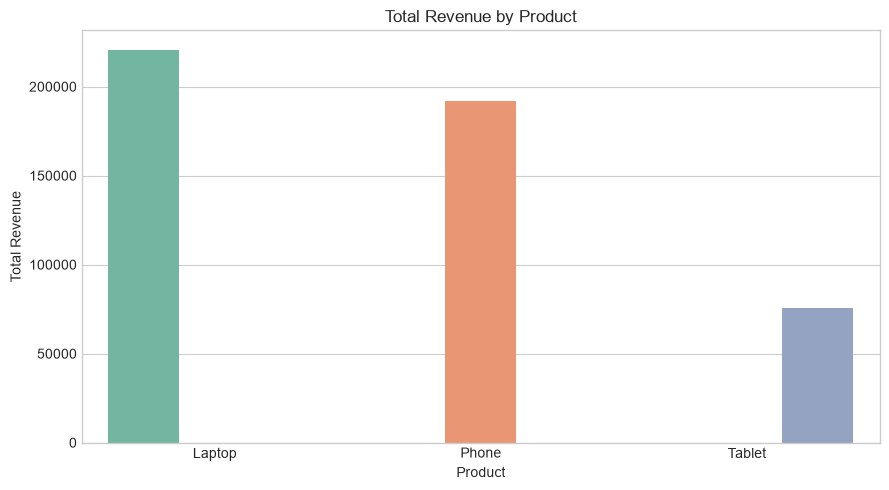

In [16]:
plot_data = product_summary.reset_index()

plt.figure(figsize=(9, 5))
sns.barplot(data=plot_data, x="product", y="total_revenue", hue="product", legend=False)
plt.title("Total Revenue by Product")
plt.xlabel("Product")
plt.ylabel("Total Revenue")
plt.tight_layout()
plt.show()

## 12. Visualization 2: Daily Revenue Trend

Time-series aggregation reduces transaction-level records to one value per day. A seven-day moving average smooths daily variation and highlights the short-term direction without removing the original observations.

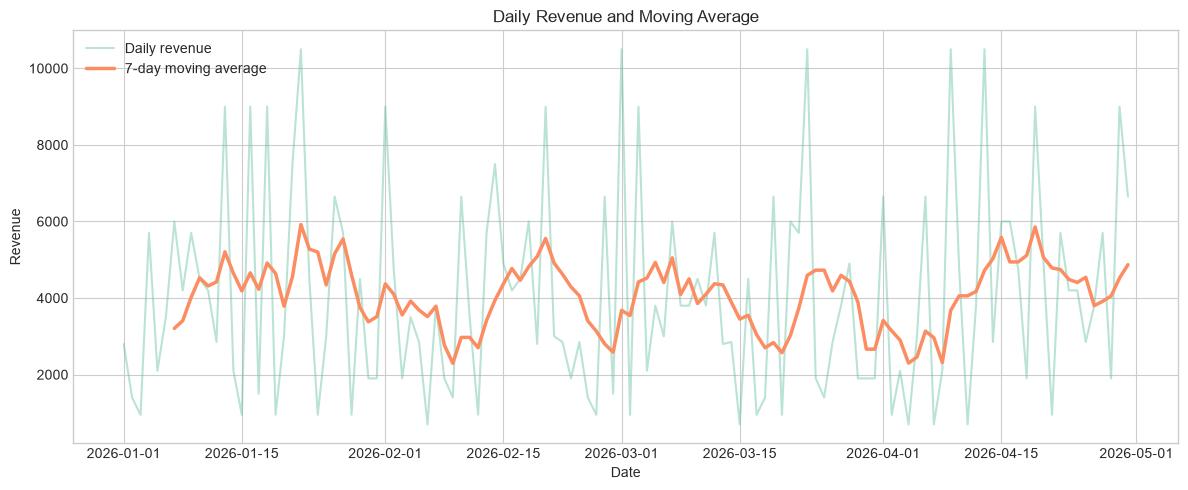

In [17]:
daily_revenue = clean.groupby("date", as_index=False)["revenue"].sum()
daily_revenue["7_day_average"] = daily_revenue["revenue"].rolling(7).mean()

plt.figure(figsize=(12, 5))
plt.plot(daily_revenue["date"], daily_revenue["revenue"], alpha=0.45, label="Daily revenue")
plt.plot(daily_revenue["date"], daily_revenue["7_day_average"], linewidth=2.5, label="7-day moving average")
plt.title("Daily Revenue and Moving Average")
plt.xlabel("Date")
plt.ylabel("Revenue")
plt.legend()
plt.tight_layout()
plt.show()

## 13. Visualization 3: Correlation Heatmap

Correlation measures linear association between numeric variables. Values range from -1 to 1. A large positive or negative value can identify a relationship worth investigating, but correlation does not prove causation and may be influenced by other variables.

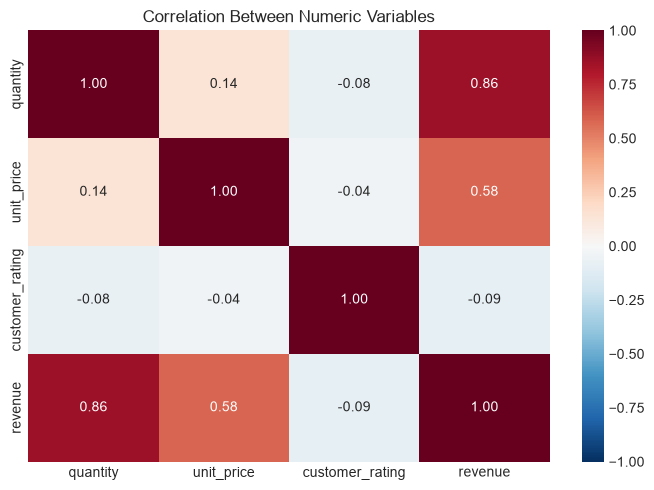

In [18]:
correlation = clean[[
    "quantity", "unit_price", "customer_rating", "revenue"
]].corr()

plt.figure(figsize=(7, 5))
sns.heatmap(correlation, annot=True, cmap="RdBu_r", center=0, vmin=-1, vmax=1, fmt=".2f")
plt.title("Correlation Between Numeric Variables")
plt.tight_layout()
plt.show()

## 14. Export the Prepared Dataset

A cleaned dataset can be saved for reporting, modeling, or later analysis. Setting `index=False` prevents pandas from writing the DataFrame index as an extra CSV column. The file is written to the notebook's current working directory.

In [19]:
output_path = "clean_sales_data.csv"
clean.to_csv(output_path, index=False)
print(f"Saved {len(clean)} rows to {output_path}")

Saved 120 rows to clean_sales_data.csv


## Data-Science Workflow Summary

1. **Define the question:** decide what must be measured or predicted.
2. **Collect data:** record its source, time range, units, and limitations.
3. **Inspect quality:** examine types, missing values, duplicates, ranges, and unexpected categories.
4. **Clean and transform:** make documented decisions rather than silently changing values.
5. **Explore:** use descriptive statistics, grouped summaries, and visualizations to identify patterns.
6. **Interpret carefully:** distinguish association from causation and consider sampling bias or missing context.
7. **Communicate and reproduce:** use clear labels, preserve code, and state assumptions so that another person can repeat the analysis.

This workflow prepares data for the regression and classification methods covered in the next notebooks.